Accuracy: 0.8400

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.86      0.91      3882
           1       0.13      0.37      0.19       206

    accuracy                           0.84      4088
   macro avg       0.55      0.62      0.55      4088
weighted avg       0.92      0.84      0.87      4088

Confusion Matrix Array:
[[3357  525]
 [ 129   77]]


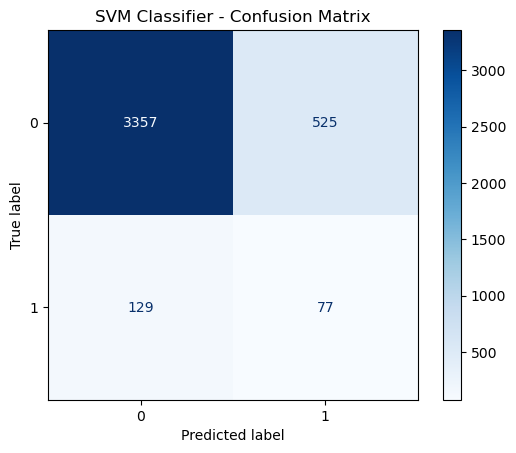

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv(r"C:\Users\R5b\Downloads\archive\stroke_preprocessed.csv")
df=pd.get_dummies(df, drop_first=True)

X = df.drop("stroke", axis=1)
y = df["stroke"]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, random_state=42)

s=StandardScaler() #Feature Scaling

X_train_s=s.fit_transform(X_train)
X_test_s=s.transform(X_test)

model = SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42)  #rbf=Radial Basis function,c=regularisation parameter

model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix Array:")
print(cm)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("SVM Classifier - Confusion Matrix")
plt.show()
